<a href="https://colab.research.google.com/github/tumatidurga/collab/blob/main/crop_recommendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

**Load the Dataset**

In [3]:
from google.colab import files

uploaded = files.upload()

Saving Crop_recommendation.csv to Crop_recommendation.csv


In [4]:
# Load the dataset
df = pd.read_csv('Crop_recommendation.csv')

**Basic Data Inspection (First 5 rows)**

In [5]:
# Display first 5 rows
print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice


**Dataset Shape (rows & columns)**

In [6]:
# Shape of the dataset
print("Shape of the dataset (rows, columns):")
print(df.shape)

Shape of the dataset (rows, columns):
(2200, 8)


**Data Columns**

In [7]:
# List of columns
print("Columns in the dataset:")
print(df.columns)

Columns in the dataset:
Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')


**Data Types of Each Column**

In [8]:
# Data types of each column
print("Data types of each column:")
print(df.dtypes)

Data types of each column:
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object


**Statistical Summary**

In [9]:
# Statistical summary
print("Statistical summary of numerical columns:")
print(df.describe())

Statistical summary of numerical columns:
                 N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.149091    25.616244    71.481779   
std      36.917334    32.985883    50.647931     5.063749    22.263812   
min       0.000000     5.000000     5.000000     8.825675    14.258040   
25%      21.000000    28.000000    20.000000    22.769375    60.261953   
50%      37.000000    51.000000    32.000000    25.598693    80.473146   
75%      84.250000    68.000000    49.000000    28.561654    89.948771   
max     140.000000   145.000000   205.000000    43.675493    99.981876   

                ph     rainfall  
count  2200.000000  2200.000000  
mean      6.469480   103.463655  
std       0.773938    54.958389  
min       3.504752    20.211267  
25%       5.971693    64.551686  
50%       6.425045    94.867624  
75%       6.923643   124.267508  
max       9.935091 

**Check for Null Values**

In [10]:
# Check for null values
print("Null values in each column:")
print(df.isnull().sum())

Null values in each column:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


**Data Information (Memory & Non-null counts)**

In [11]:
# Info about dataset
print("Dataset info:")
df.info()

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


**Unique Values in Each Column**

In [12]:
# Unique values in each column
for col in df.columns:
    print(f"Unique values in {col}: {df[col].nunique()}")

Unique values in N: 137
Unique values in P: 117
Unique values in K: 73
Unique values in temperature: 2200
Unique values in humidity: 2200
Unique values in ph: 2200
Unique values in rainfall: 2200
Unique values in label: 22


**Value Counts for Target Variable 'label'**

In [13]:
# Distribution of target variable 'label'
print("Value counts for 'label':")
print(df['label'].value_counts())

Value counts for 'label':
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


**Visualize Target Distribution**

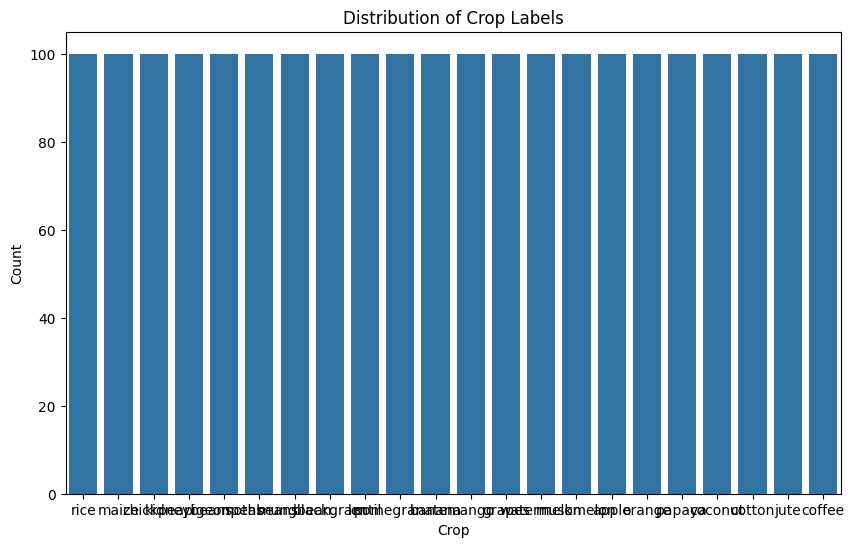

In [14]:
# Plot distribution of 'label'
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='label')
plt.title('Distribution of Crop Labels')
plt.xlabel('Crop')
plt.ylabel('Count')
plt.show()

**Correlation Matrix Heatmap**

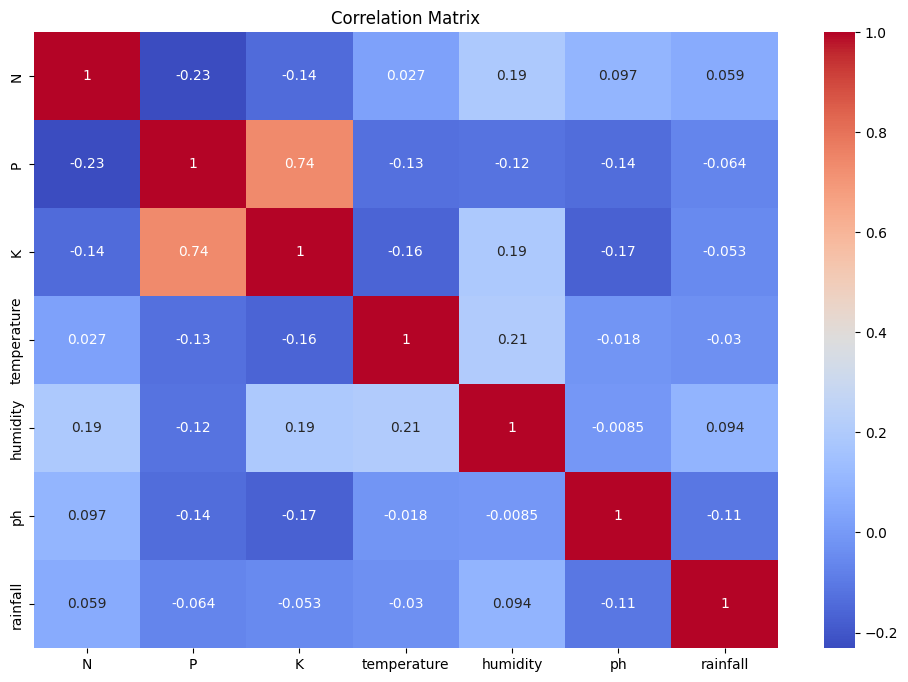

In [16]:
# Select only numeric columns for correlation
numeric_cols = df.select_dtypes(include=[np.number])

# Plot correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

**Encode Target Variable**

In [17]:
# Encode 'label' to numerical values
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

**Prepare Features and Target**

In [18]:
# Features and target
X = df.drop(['label', 'label_encoded'], axis=1)
y = df['label_encoded']

**Split Data into Training & Testing Sets**

In [19]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**Visualize Data Distributions**

In [20]:
# Pairplot to visualize relationships (optional)
# sns.pairplot(df, hue='label')
# plt.show()

** Initialize & Train the Model**

In [21]:
# Initialize Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

**Make Predictions & Evaluate**

In [22]:
# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Classification report
print("Classification report:\n", classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 99.55%
Classification report:
               precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1

**Confusion Matrix Visualization**

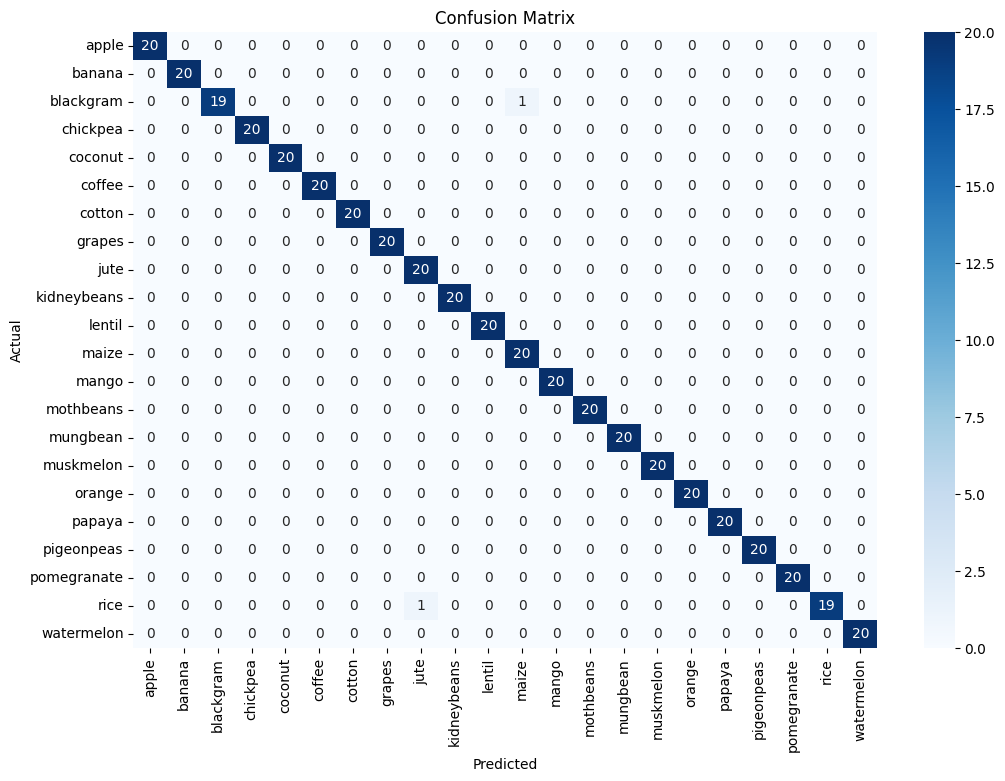

In [23]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

**Custom Prediction**

In [25]:
# Example feature values (replace these with actual values you want to test)
N_value = 90
P_value = 42
K_value = 43
temperature_value = 20.88
humidity_value = 80.50
ph_value = 6.5
rainfall_value = 202.9

# Create the input array
sample_input = np.array([[N_value, P_value, K_value, temperature_value, humidity_value, ph_value, rainfall_value]])

# Predict crop
predicted_encoded = model.predict(sample_input)
predicted_crop = le.inverse_transform(predicted_encoded)
print(f"Predicted Crop: {predicted_crop[0]}")

Predicted Crop: rice


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
